In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# Property Data

In [2]:
df_raw = pd.read_csv("2024-08-Buy-property_info.csv", encoding="utf-8-sig")
df_raw.drop(columns=["Unnamed: 0.1", "Unnamed: 0"], inplace=True)
print(len(df_raw))
df_raw.head()

89652


,Location,URL,SKU,Title,Price,Category,Num_Bedrooms,Num_Bathrooms,Floor_Area,Land_Area,Geo_Locations,Description,Agent_Name,Agent_Links,Agent_Verifications,File
0,"Amparo, Caloocan",https://www.lamudi.com.ph/projects/amparo-resi...,HO5CEE34F0060ECPH,7.2M single attached house and lot for sale at...,7200000,house,3.0,2.0,147.0,103.0,"[121.0769537,14.7471848]","Project- ELIORA , AMPARO SUBDIVISION Location-...",Evelyn Samaniego,https://www.lamudi.com.ph/evelyn-samaniego/,FULLY VERIFIED,Caloocan
1,Caloocan,https://www.lamudi.com.ph/buy/metro-manila/cal...,CD66D1B50AECE7EPH,Caloocan City RFO Condo beside Lrt Monumento,3100000,condo,1.0,1.0,21.7,NaN,"[120.99083,14.65739]",Reasons why you should buy condo here at Torre...,Mariz Lapuz,https://www.lamudi.com.ph/-agn-36444/,FULLY VERIFIED,Caloocan
2,"Amparo, Caloocan",https://www.lamudi.com.ph/buy/metro-manila/cal...,LA66C596CFA8463PH,"850sqm Vacant Lot in Makabud Street, Amparo, N...",17000000,land,NaN,NaN,NaN,850.0,"[121.0769537,14.7471848]",Lot Area: 850 sqm Frontage: 24.54 m Located in...,Paolo Bellosillo,https://www.lamudi.com.ph/-25377/,FULLY VERIFIED,Caloocan
3,"Grace Park East, Caloocan",https://www.lamudi.com.ph/buy/metro-manila/cal...,CD66C1D00AA6DD1PH,Pre Selling 2BR 97sqm in Caloocan City near Ar...,11900000,condo,3.0,2.0,97.0,NaN,"[120.9905434,14.6514006]",CALINEA TOWER PRE SELLING 3 BEDROOM 97 SQM IN ...,Ailyn Vigilla,https://www.lamudi.com.ph/ailyn-vigilla-agn-15...,FULLY VERIFIED,Caloocan
4,"Grace Park East, Caloocan",https://www.lamudi.com.ph/buy/metro-manila/cal...,CD66C6B155BF32BPH,3BR 97sqm Pre Selling in Caloocan City near Sq...,11900000,condo,3.0,2.0,97.0,NaN,"[120.9905434,14.6514006]",CALINEA TOWER PRE SELLING 3 BEDROOM 97 SQM IN ...,Ailyn Vigilla,https://www.lamudi.com.ph/ailyn-vigilla-agn-15...,FULLY VERIFIED,Caloocan


In [3]:
df = df_raw.copy()

## Data Cleaning

In [4]:
for column in df.columns:
    print(column, df.columns.isna().sum())

Location 0
URL 0
SKU 0
Title 0
Price 0
Category 0
Num_Bedrooms 0
Num_Bathrooms 0
Floor_Area 0
Land_Area 0
Geo_Locations 0
Description 0
Agent_Name 0
Agent_Links 0
Agent_Verifications 0
File 0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89652 entries, 0 to 89651
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Location             89652 non-null  object 
 1   URL                  89652 non-null  object 
 2   SKU                  89652 non-null  object 
 3   Title                89647 non-null  object 
 4   Price                89652 non-null  object 
 5   Category             89652 non-null  object 
 6   Num_Bedrooms         75491 non-null  float64
 7   Num_Bathrooms        71399 non-null  float64
 8   Floor_Area           78685 non-null  float64
 9   Land_Area            58203 non-null  float64
 10  Geo_Locations        89652 non-null  object 
 11  Description          89469 non-null  object 
 12  Agent_Name           89652 non-null  object 
 13  Agent_Links          89652 non-null  object 
 14  Agent_Verifications  89652 non-null  object 
 15  File                 89652 non-null 

### Removal

In [6]:
print(len(df))
df = df[-(df["Price"]=="Contact agent for price")]
print(len(df))

89652
87136


In [7]:
land_check = df[(df["Category"]=="Land") & (df["Land_Area"].isna() | df["Land_Area"]==0)]
print(len(land_check))

0


### Fix Data Type & Fill Null

In [8]:
for var in ["Price", "Num_Bedrooms", "Num_Bathrooms", "Floor_Area", "Land_Area"]:
    df[var].fillna(0, inplace=True)
    df[var] = pd.to_numeric(df[var], errors='coerce')
for var in ["Title", "Description"]:
    df[var].fillna("", inplace=True)
    df[var] = df[var].astype(str)

C:\Users\Dianne Yumol\AppData\Local\Temp\ipykernel_10500\3371331411.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[var].fillna(0, inplace=True)
C:\Users\Dianne Yumol\AppData\Local\Temp\ipykernel_10500\3371331411.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

In [9]:
def split_geo_locations(location):
    location = location.strip("[]").split(",")
    return float(location[0]), float(location[1])
df[['Latitude', 'Longitude']] = df['Geo_Locations'].apply(lambda x: pd.Series(split_geo_locations(x)))
df.drop(columns="Geo_Locations", inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87136 entries, 0 to 89651
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Location             87136 non-null  object 
 1   URL                  87136 non-null  object 
 2   SKU                  87136 non-null  object 
 3   Title                87136 non-null  object 
 4   Price                87136 non-null  float64
 5   Category             87136 non-null  object 
 6   Num_Bedrooms         87136 non-null  float64
 7   Num_Bathrooms        87136 non-null  float64
 8   Floor_Area           87136 non-null  float64
 9   Land_Area            87136 non-null  float64
 10  Description          87136 non-null  object 
 11  Agent_Name           87136 non-null  object 
 12  Agent_Links          87136 non-null  object 
 13  Agent_Verifications  87136 non-null  object 
 14  File                 87136 non-null  object 
 15  Latitude             87136 non-null  floa

## Duplicate Check

In [11]:
df = df.drop_duplicates()
print(len(df))

86877


### SKU

In [12]:
SKU_duplicates = df["SKU"].duplicated()
print(len(df[SKU_duplicates]))
df[SKU_duplicates].sort_values("SKU").head()

141


,Location,URL,SKU,Title,Price,Category,Num_Bedrooms,Num_Bathrooms,Floor_Area,Land_Area,Description,Agent_Name,Agent_Links,Agent_Verifications,File,Latitude,Longitude
72700,"Rosario, Pasig",https://www.lamudi.com.ph/buy/metro-manila/pas...,AP5C4B0B9D50BCEPH,Dormitory For Sale at the Heart of Pasig.,27000000.0,apartment,16.0,7.0,350.0,0.0,DORMITORY for Sale at the Heart of Pasig.Lifeh...,Ludivica A. Serrano,https://www.lamudi.com.ph/ludivica-a-serrano/,FULLY VERIFIED,Rizal,121.089097,14.588464
30518,"Valenzuela, Makati",https://www.lamudi.com.ph/buy/metro-manila/mak...,AP62418DAA64179PH,For Sale 6 Door Apartments with Tenants in Bar...,60000000.0,apartment,6.0,6.0,320.0,0.0,320 SQM Taguig St. Barangay Valenzuela Village...,Christine Baliza,https://www.lamudi.com.ph/christine-baliza-agn/,FULLY VERIFIED,Mandaluyong,121.024192,14.571361
79014,"Santo Niño, Cainta",https://www.lamudi.com.ph/buy/rizal/cainta/for...,AP6243F5E1D37CFPH,For Sale Apartment in Cainta Rizal,27000000.0,apartment,24.0,0.0,515.0,0.0,4-storey apartment Floor area per unit 38-40 ...,Rose Thomas,https://www.lamudi.com.ph/my-hometown-realty-d...,SEMI VERIFIED,San Juan,121.119199,14.587325
88271,"Pembo, Makati",https://www.lamudi.com.ph/buy/metro-manila/mak...,AP62EB8959B7CCAPH,"San Francisco Street, Pembo Dormitory Building...",28000000.0,apartment,10.0,19.0,300.0,0.0,"San Francisco Street, Pembo, Makati City Lot a...",Jose Mari Gutierrez,https://www.lamudi.com.ph/-agn-49566/,FULLY VERIFIED,Taguig,121.057819,14.544140
30516,"Valenzuela, Makati",https://www.lamudi.com.ph/buy/metro-manila/mak...,AP631FF4F3D0F39PH,Apartment For Sale in Makati,45000000.0,apartment,4.0,5.0,343.0,0.0,"APARTMENT FOR SALE PHP45,000.000,00 NET 343 SQ...",Gloria Balane-Rafer,https://www.lamudi.com.ph/gloria-balane-rafer-...,FULLY VERIFIED,Mandaluyong,121.024192,14.571361


In [13]:
print(len(df))
df = df[~SKU_duplicates]
print(len(df))

86877
86736


In [14]:
df.to_csv("20241118 Processed File v1 - No SKU Duplicates.csv", encoding="utf-8-sig", index=False)

### Description & Title & Others

In [15]:
df["Concat"] = df.iloc[:, 4:10].apply(lambda row: ' '.join(row.values.astype(str)), axis=1)
concat_duplicates = df["Concat"].duplicated()
df[concat_duplicates].head()

,Location,URL,SKU,Title,Price,Category,Num_Bedrooms,Num_Bathrooms,Floor_Area,Land_Area,Description,Agent_Name,Agent_Links,Agent_Verifications,File,Latitude,Longitude,Concat
4,"Grace Park East, Caloocan",https://www.lamudi.com.ph/buy/metro-manila/cal...,CD66C6B155BF32BPH,3BR 97sqm Pre Selling in Caloocan City near Sq...,11900000.0,condo,3.0,2.0,97.00,0.00,CALINEA TOWER PRE SELLING 3 BEDROOM 97 SQM IN ...,Ailyn Vigilla,https://www.lamudi.com.ph/ailyn-vigilla-agn-15...,FULLY VERIFIED,Caloocan,120.990543,14.651401,11900000.0 condo 3.0 2.0 97.0 0.0
6,"Grace Park East, Caloocan",https://www.lamudi.com.ph/buy/metro-manila/cal...,CD66C477480BB48PH,3BR 97 sqm Pre Selling in Quezon City Calinea ...,11900000.0,condo,3.0,2.0,97.00,0.00,CALINEA TOWER PRE SELLING 3 BEDROOM 97 SQM IN ...,Ailyn Vigilla,https://www.lamudi.com.ph/ailyn-vigilla-agn-15...,FULLY VERIFIED,Caloocan,120.990543,14.651401,11900000.0 condo 3.0 2.0 97.0 0.0
7,"Grace Park East, Caloocan",https://www.lamudi.com.ph/buy/metro-manila/cal...,CD66C4A17042038PH,3BR 97sqm Pre Selling in Caloocan City near No...,11900000.0,condo,3.0,2.0,97.00,0.00,CALINEA TOWER PRE SELLING 3 BEDROOM 97 SQM IN ...,Ailyn Vigilla,https://www.lamudi.com.ph/ailyn-vigilla-agn-15...,FULLY VERIFIED,Caloocan,120.990543,14.651401,11900000.0 condo 3.0 2.0 97.0 0.0
8,"Grace Park East, Caloocan",https://www.lamudi.com.ph/buy/metro-manila/cal...,CD66C6C949EE24EPH,Pre Selling 3BR 97sqm in Caloocan City near SM...,11900000.0,condo,3.0,2.0,97.00,0.00,CALINEA TOWER PRE SELLING 3 BEDROOM 97 SQM IN ...,Ailyn Vigilla,https://www.lamudi.com.ph/ailyn-vigilla-agn-15...,FULLY VERIFIED,Caloocan,120.990543,14.651401,11900000.0 condo 3.0 2.0 97.0 0.0
41,"Amparo, Caloocan",https://www.lamudi.com.ph/projects/amparo-subd...,HO6501855B414E1PH,Corner House & Lot FOR SALE in Amparo Caloocan...,7800000.0,house,3.0,2.5,98.96,76.67,Project- SINGLE ATTACHED HOUSE & LOT Location-...,Keziah Samaniego,https://www.lamudi.com.ph/evelyn-samaniego-47598/,FULLY VERIFIED,Caloocan,121.076954,14.747185,7800000.0 house 3.0 2.5 98.96 76.67


In [16]:
title_desc_duplicates = (df["Description"]!="") & (df["Description"].duplicated()) & (df["Title"].duplicated()) & concat_duplicates
print(len(df[title_desc_duplicates]))
check = df[title_desc_duplicates]
df[title_desc_duplicates].sort_values("Title").head()

7764


,Location,URL,SKU,Title,Price,Category,Num_Bedrooms,Num_Bathrooms,Floor_Area,Land_Area,Description,Agent_Name,Agent_Links,Agent_Verifications,File,Latitude,Longitude,Concat
68540,"Cubao, Quezon City",https://www.lamudi.com.ph/buy/metro-manila/que...,HO66BEE1B39467EPH,"""Prime Investment Opportunity: 600 sqm Lot in ...",60000000.0,house,6.0,6.0,750.0,600.0,"""Discover endless possibilities with this prim...",Evelyn Perez-Dumdum,https://www.lamudi.com.ph/evelyn-perez-dumdum/,FULLY VERIFIED,Quezon City,121.04505,14.625980,60000000.0 house 6.0 6.0 750.0 600.0
68539,"Cubao, Quezon City",https://www.lamudi.com.ph/buy/metro-manila/que...,HO66BEE16252143PH,"""Prime Investment Opportunity: 600 sqm Lot in ...",60000000.0,house,6.0,6.0,750.0,600.0,"""Discover endless possibilities with this prim...",Evelyn Perez-Dumdum,https://www.lamudi.com.ph/evelyn-perez-dumdum/,FULLY VERIFIED,Quezon City,121.05720,14.617770,60000000.0 house 6.0 6.0 750.0 600.0
68561,"Pinagkaisahan, Quezon City",https://www.lamudi.com.ph/buy/metro-manila/que...,HO66BEE40DB37BBPH,"""Prime Investment Opportunity: 600 sqm Lot in ...",60000000.0,house,6.0,6.0,750.0,600.0,"""Discover endless possibilities with this prim...",Evelyn Perez-Dumdum,https://www.lamudi.com.ph/evelyn-perez-dumdum/,FULLY VERIFIED,Quezon City,121.04505,14.625980,60000000.0 house 6.0 6.0 750.0 600.0
68570,"Pinagkaisahan, Quezon City",https://www.lamudi.com.ph/buy/metro-manila/que...,HO66BEE434CBB1FPH,"""Prime Investment Opportunity: 600 sqm Lot in ...",60000000.0,house,6.0,6.0,750.0,600.0,"""Discover endless possibilities with this prim...",Evelyn Perez-Dumdum,https://www.lamudi.com.ph/evelyn-perez-dumdum/,FULLY VERIFIED,Quezon City,121.04426,14.626617,60000000.0 house 6.0 6.0 750.0 600.0
68567,"Pinagkaisahan, Quezon City",https://www.lamudi.com.ph/buy/metro-manila/que...,HO66BEE44347031PH,"""Prime Investment Opportunity: 600 sqm Lot in ...",60000000.0,house,6.0,6.0,750.0,600.0,"""Discover endless possibilities with this prim...",Evelyn Perez-Dumdum,https://www.lamudi.com.ph/evelyn-perez-dumdum/,FULLY VERIFIED,Quezon City,121.04426,14.626617,60000000.0 house 6.0 6.0 750.0 600.0


In [17]:
print(len(df))
df = df[~title_desc_duplicates]
print(len(df))

86736
78972


In [18]:
df.to_csv("20241118 Processed File v2 - No SKU and Other Duplicates.csv", encoding="utf-8-sig", index=False)

In [19]:
#ISSUE: Seems to be same proeprty but price or other features change
df[df["Title"]=="Brand New Semi Furnished House and Lot with Pool in Greenwoods Executive Village"]

,Location,URL,SKU,Title,Price,Category,Num_Bedrooms,Num_Bathrooms,Floor_Area,Land_Area,Description,Agent_Name,Agent_Links,Agent_Verifications,File,Latitude,Longitude,Concat
47449,"San Miguel, Pasig",https://www.lamudi.com.ph/buy/metro-manila/pas...,HO65F85AC0A987FPH,Brand New Semi Furnished House and Lot with Po...,25000000.0,house,5.0,5.0,150.0,350.0,Brand New Semi Furnished House and Lot with Po...,Joshua Tanato,https://www.lamudi.com.ph/-agn-52081/,FULLY VERIFIED,Pasig,121.092265,14.567197,25000000.0 house 5.0 5.0 150.0 350.0
47465,"San Miguel, Pasig",https://www.lamudi.com.ph/buy/metro-manila/pas...,HO65F85B220034BPH,Brand New Semi Furnished House and Lot with Po...,26500000.0,house,5.0,5.0,150.0,350.0,Brand New Semi Furnished House and Lot with Po...,Joshua Tanato,https://www.lamudi.com.ph/-agn-52081/,FULLY VERIFIED,Pasig,121.092265,14.567197,26500000.0 house 5.0 5.0 150.0 350.0
48074,"San Miguel, Pasig",https://www.lamudi.com.ph/buy/metro-manila/pas...,HO66912A1781F28PH,Brand New Semi Furnished House and Lot with Po...,26500000.0,house,5.0,5.0,250.0,150.0,Brand New Semi Furnished House and Lot with Po...,Joshua Tanato,https://www.lamudi.com.ph/-agn-52081/,FULLY VERIFIED,Pasig,121.092265,14.567197,26500000.0 house 5.0 5.0 250.0 150.0
48878,"San Miguel, Pasig",https://www.lamudi.com.ph/new-developments/gre...,HO6633C2268726BPH,Brand New Semi Furnished House and Lot with Po...,25000000.0,house,5.0,5.0,350.0,150.0,Brand New Semi Furnished House and Lot with Po...,Joshua Tanato,https://www.lamudi.com.ph/-agn-52081/,FULLY VERIFIED,Pasig,121.092265,14.567197,25000000.0 house 5.0 5.0 350.0 150.0
48881,"San Miguel, Pasig",https://www.lamudi.com.ph/new-developments/gre...,HO662902C9527E1PH,Brand New Semi Furnished House and Lot with Po...,26500000.0,house,5.0,5.0,350.0,150.0,Brand New Semi Furnished House and Lot with Po...,Joshua Tanato,https://www.lamudi.com.ph/-agn-52081/,FULLY VERIFIED,Pasig,121.092265,14.567197,26500000.0 house 5.0 5.0 350.0 150.0
49140,"San Miguel, Pasig",https://www.lamudi.com.ph/buy/metro-manila/pas...,HO66795A5A17FCDPH,Brand New Semi Furnished House and Lot with Po...,25000000.0,house,5.0,5.0,350.0,50.0,Brand New Semi Furnished House and Lot with Po...,Joshua Tanato,https://www.lamudi.com.ph/-agn-52081/,FULLY VERIFIED,Pasig,121.092265,14.567197,25000000.0 house 5.0 5.0 350.0 50.0
49347,"San Miguel, Pasig",https://www.lamudi.com.ph/buy/metro-manila/pas...,HO66741D15963F1PH,Brand New Semi Furnished House and Lot with Po...,25000000.0,house,6.0,6.0,350.0,150.0,Brand New Semi Furnished House and Lot with Po...,Joshua Tanato,https://www.lamudi.com.ph/-agn-52081/,FULLY VERIFIED,Pasig,121.092265,14.567197,25000000.0 house 6.0 6.0 350.0 150.0
49394,"San Miguel, Pasig",https://www.lamudi.com.ph/buy/metro-manila/pas...,HO661950E671780PH,Brand New Semi Furnished House and Lot with Po...,2650000.0,house,5.0,5.0,350.0,150.0,Brand New Semi Furnished House and Lot with Po...,Joshua Tanato,https://www.lamudi.com.ph/-agn-52081/,FULLY VERIFIED,Pasig,121.092265,14.567197,2650000.0 house 5.0 5.0 350.0 150.0
49575,"San Miguel, Pasig",https://www.lamudi.com.ph/buy/metro-manila/pas...,HO662BD02BEE6EDPH,Brand New Semi Furnished House and Lot with Po...,25500000.0,house,5.0,5.0,350.0,150.0,Brand New Semi Furnished House and Lot with Po...,Joshua Tanato,https://www.lamudi.com.ph/-agn-52081/,FULLY VERIFIED,Pasig,121.092265,14.567197,25500000.0 house 5.0 5.0 350.0 150.0


# QGIS

In [20]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt 
import seaborn as sns

In [21]:
RR = pd.read_csv("20241911v RR.csv", encoding="utf-8-sig")
RR['Matched_Zonal_Value'] = RR['Matched_Zonal_Value'].str.strip()
RR = RR[~RR['Matched_Zonal_Value'].str.contains(r'\*', na=False)]
RR['Matched_Zonal_Value'] = RR['Matched_Zonal_Value'].astype(float)
RR = RR[~RR["Matched_Zonal_Value"].isna()]
print(len(RR))

45770


C:\Users\Dianne Yumol\AppData\Local\Temp\ipykernel_10500\1495661556.py:1: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  RR = pd.read_csv("20241911v RR.csv", encoding="utf-8-sig")


In [22]:
CR = pd.read_csv("20241911v CR.csv", encoding="utf-8-sig")
CR['Matched_Zonal_Value'] = CR['Matched_Zonal_Value'].str.strip()
CR = CR[~CR['Matched_Zonal_Value'].str.contains(r'\*', na=False)]
CR['Matched_Zonal_Value'] = CR['Matched_Zonal_Value'].astype(float)
CR = CR[~CR["Matched_Zonal_Value"].isna()]
print(len(CR))

3262


In [23]:
general_df = pd.merge(RR, CR, "outer")
general_df
len(general_df) == len(RR) + len(CR)

True

In [24]:
general_df.head()

,Location,URL,SKU,Title,Price,Category,Num_Bedrooms,Num_Bathrooms,Floor_Area,Land_Area,...,SchoolHubName,SchoolHubDist,BusCount,HospitalCount,MallCount,SchoolCount,Concat,Property Type,Processed_Location,Matched_Zonal_Value
0,"A. Dalusag, General Emilio Aguinaldo",https://www.lamudi.com.ph/buy/cavite/general-e...,LA649F998E6B5A3PH,"Affordable 500 sqm Residential Lot in Bailen, ...",1750000.0,land,0.0,0.0,0.0,500.0,...,w791652799,0.267214,0,0,0,2,1750000.0 land 0.0 0.0 0.0 500.0,CR,dalusag general emilio aguinaldo,106000.0
1,"A. Dalusag, General Emilio Aguinaldo",https://www.lamudi.com.ph/buy/cavite/general-e...,LA6576C8D9D7C96PH,Affordable Residential Lot near East west Road...,1750000.0,land,0.0,0.0,0.0,500.0,...,w791652799,0.267214,0,0,0,2,1750000.0 land 0.0 0.0 0.0 500.0,CR,dalusag general emilio aguinaldo,84000.0
2,"A. Dalusag, General Emilio Aguinaldo",https://www.lamudi.com.ph/buy/cavite/general-e...,LA6639AADDD2D37PH,Beautiful and Cool Place Resifarm Hacienda,1750000.0,land,0.0,0.0,0.0,500.0,...,w791652799,0.267214,0,0,0,2,1750000.0 land 0.0 0.0 0.0 500.0,CR,dalusag general emilio aguinaldo,84000.0
3,"A. Dalusag, General Emilio Aguinaldo",https://www.lamudi.com.ph/buy/cavite/general-e...,LA6576BFC5DFCC3PH,For Sale 500 sqm Farm Residential Lot in A. Da...,1750000.0,land,0.0,0.0,0.0,500.0,...,w791652799,0.267214,0,0,0,2,1750000.0 land 0.0 0.0 0.0 500.0,CR,dalusag general emilio aguinaldo,32000.0
4,"A. Dalusag, General Emilio Aguinaldo",https://www.lamudi.com.ph/buy/cavite/general-e...,LA64AB80E669B28PH,For Sale Farm Lot Affordable Near East west Road,1600000.0,land,0.0,0.0,0.0,500.0,...,w791652799,0.267214,0,0,0,2,1600000.0 land 0.0 0.0 0.0 500.0,CR,dalusag general emilio aguinaldo,84000.0


In [ ]:
#general_df.to_csv("20241124 Gen.csv", encoding="utf-8-sig", index=False)

## Second Cleaning

In [6]:
qgis_df = pd.read_csv("20241119v Properties with Distance and Count.csv", encoding="utf-8-sig")
print(len(qgis_df))
qgis_df.head()

80223


,Location,URL,SKU,Title,Price,Category,Num_Bedroo,Num_Bathro,Floor_Area,Land_Area,...,HospitalHubName,HospitalHubDist,MallHubName,MallHubDist,SchoolHubName,SchoolHubDist,BusCount,HospitalCount,MallCount,SchoolCount
0,"Amparo, Caloocan",https://www.lamudi.com.ph/projects/amparo-resi...,HO5CEE34F0060ECPH,7.2M single attached house and lot for sale at...,7200000.0,house,3.0,2.0,147.0,103.0,...,n255061867,1.316144,SM City Fairview,2.509902,w873447606,0.342505,0,0,0,5
1,Caloocan,https://www.lamudi.com.ph/buy/metro-manila/cal...,CD66D1B50AECE7EPH,Caloocan City RFO Condo beside Lrt Monumento,3100000.0,condo,1.0,1.0,21.7,0.0,...,n255050207,0.138596,North Mall,0.708891,w40941344,0.295216,14,7,3,15
2,"Amparo, Caloocan",https://www.lamudi.com.ph/buy/metro-manila/cal...,LA66C596CFA8463PH,"850sqm Vacant Lot in Makabud Street, Amparo, N...",17000000.0,land,0.0,0.0,0.0,850.0,...,n255061867,1.316144,SM City Fairview,2.509902,w873447606,0.342505,0,0,0,5
3,"Grace Park East, Caloocan",https://www.lamudi.com.ph/buy/metro-manila/cal...,CD66C1D00AA6DD1PH,Pre Selling 2BR 97sqm in Caloocan City near Ar...,11900000.0,condo,3.0,2.0,97.0,0.0,...,n255066691,0.261535,North Mall,0.698302,w40941344,0.414120,15,10,2,15
4,"Grace Park East, Caloocan",https://www.lamudi.com.ph/buy/metro-manila/cal...,CD66C6B155BF32BPH,3BR 97sqm Pre Selling in Caloocan City near Sq...,11900000.0,condo,3.0,2.0,97.0,0.0,...,n255066691,0.261535,North Mall,0.698302,w40941344,0.414120,15,10,2,15


In [7]:
qgis_df.rename(columns={"Num_Bedroo": "Num_Bedrooms", "Num_Bathro": "Num_Bathrooms", "Descriptio": "Description", "Agent_Veri": "Agent_Verification"}, inplace=True)

In [8]:
# Fixing data type
for var in ["Price", "Num_Bedrooms", "Num_Bathrooms", "Floor_Area", "Land_Area"]:
    qgis_df[var].fillna(0, inplace=True)
    qgis_df[var] = pd.to_numeric(qgis_df[var], errors='coerce')
for var in ["Title", "Description"]:
    qgis_df[var].fillna("", inplace=True)
    qgis_df[var] = qgis_df[var].astype(str)

# Translating common accented characters
qgis_df.replace(r"Ã±", "ñ", regex=True, inplace=True)
qgis_df.replace(r"Ã‘", "Ñ", regex=True, inplace=True)
qgis_df.replace(r"Ã©", "é", regex=True, inplace=True)

# Removing all characters that are not letters, numbers, common punctuation, or ñÑé
# Reduce any amount of whitespace to a single space
def clean_text(text):
    cleaned_text = re.sub(r"[^a-zA-Z0-9.,!? \'\"ñÑé]+", " ", text)
    cleaned_text = re.sub(r"\s+", " ", cleaned_text)
    
    return cleaned_text

qgis_df['Title'] = qgis_df['Title'].apply(clean_text)
qgis_df['Description'] = qgis_df['Description'].apply(clean_text)

In [9]:
rent_properties = qgis_df[qgis_df["URL"].str.contains(r".*rent.*")]
rent_properties.head()

,Location,URL,SKU,Title,Price,Category,Num_Bedrooms,Num_Bathrooms,Floor_Area,Land_Area,...,HospitalHubName,HospitalHubDist,MallHubName,MallHubDist,SchoolHubName,SchoolHubDist,BusCount,HospitalCount,MallCount,SchoolCount
23,"Amparo, Caloocan",https://www.lamudi.com.ph/projects/amparo/rent...,HO63A31ECE3C309PH,Zero Down Rent to Own Townhouse 3BR. Move in R...,2500000.0,house,3.0,1.0,40.00,19.00,...,n255061867,1.316144,SM City Fairview,2.509902,w873447606,0.342505,0,0,0,5
87,"Amparo, Caloocan",https://www.lamudi.com.ph/projects/amparo-subd...,HO5CDA7F1A7951FPH,"RFO, Rent to Own, Townhouse For Sale at Mangga...",5800000.0,house,3.0,2.0,123.52,76.91,...,r14713258,1.359740,SM City Fairview,4.033290,w932362768,0.480251,5,0,0,7
123,"Amparo, Caloocan",https://www.lamudi.com.ph/projects/amparo-subd...,HO5CEE3AEEA9BBAPH,10 DP Rent To Own Townhouse For Sale at Amparo...,5800000.0,house,3.0,2.0,123.00,76.00,...,r14713258,1.359740,SM City Fairview,4.033290,w932362768,0.480251,5,0,0,7
124,"Amparo, Caloocan",https://www.lamudi.com.ph/projects/amparo-subd...,HO5CBAC96FCE0BEPH,"Unit 7, 10 Down only, Rent to own Townhouse Fo...",5520000.0,house,3.0,2.0,123.00,76.00,...,r14713258,1.359740,SM City Fairview,4.033290,w932362768,0.480251,5,0,0,7
186,"Amparo, Caloocan",https://www.lamudi.com.ph/projects/amparo-subd...,HO5CEE32D336289PH,"RFO, Rent To Own townhouse For Sale at Amparo ...",5800000.0,house,3.0,2.0,123.00,76.00,...,n255061867,1.316144,SM City Fairview,2.509902,w873447606,0.342505,0,0,0,5


In [10]:
qgis_df["Concat"] = qgis_df.iloc[:, 4:10].apply(lambda row: ' '.join(row.values.astype(str)), axis=1)
concat_duplicates = qgis_df["Concat"].duplicated()
qgis_df[concat_duplicates].head()

,Location,URL,SKU,Title,Price,Category,Num_Bedrooms,Num_Bathrooms,Floor_Area,Land_Area,...,HospitalHubDist,MallHubName,MallHubDist,SchoolHubName,SchoolHubDist,BusCount,HospitalCount,MallCount,SchoolCount,Concat
4,"Grace Park East, Caloocan",https://www.lamudi.com.ph/buy/metro-manila/cal...,CD66C6B155BF32BPH,3BR 97sqm Pre Selling in Caloocan City near Sq...,11900000.0,condo,3.0,2.0,97.00,0.00,...,0.261535,North Mall,0.698302,w40941344,0.414120,15,10,2,15,11900000.0 condo 3.0 2.0 97.0 0.0
6,"Grace Park East, Caloocan",https://www.lamudi.com.ph/buy/metro-manila/cal...,CD66C477480BB48PH,3BR 97 sqm Pre Selling in Quezon City Calinea ...,11900000.0,condo,3.0,2.0,97.00,0.00,...,0.261535,North Mall,0.698302,w40941344,0.414120,15,10,2,15,11900000.0 condo 3.0 2.0 97.0 0.0
7,"Grace Park East, Caloocan",https://www.lamudi.com.ph/buy/metro-manila/cal...,CD66C4A17042038PH,3BR 97sqm Pre Selling in Caloocan City near No...,11900000.0,condo,3.0,2.0,97.00,0.00,...,0.261535,North Mall,0.698302,w40941344,0.414120,15,10,2,15,11900000.0 condo 3.0 2.0 97.0 0.0
8,"Grace Park East, Caloocan",https://www.lamudi.com.ph/buy/metro-manila/cal...,CD66C6C949EE24EPH,Pre Selling 3BR 97sqm in Caloocan City near SM...,11900000.0,condo,3.0,2.0,97.00,0.00,...,0.261535,North Mall,0.698302,w40941344,0.414120,15,10,2,15,11900000.0 condo 3.0 2.0 97.0 0.0
33,"Amparo, Caloocan",https://www.lamudi.com.ph/projects/amparo-subd...,HO6501855B414E1PH,Corner House Lot FOR SALE in Amparo Caloocan C...,7800000.0,house,3.0,2.5,98.96,76.67,...,1.316144,SM City Fairview,2.509902,w873447606,0.342505,0,0,0,5,7800000.0 house 3.0 2.5 98.96 76.67


In [11]:
title_desc_duplicates = (qgis_df["Description"]!="") & (qgis_df["Description"].duplicated()) & (qgis_df["Title"].duplicated()) & concat_duplicates
print(len(qgis_df[title_desc_duplicates]))
check = qgis_df[title_desc_duplicates]
qgis_df[title_desc_duplicates].sort_values("Title").head()

8204


,Location,URL,SKU,Title,Price,Category,Num_Bedrooms,Num_Bathrooms,Floor_Area,Land_Area,...,HospitalHubDist,MallHubName,MallHubDist,SchoolHubName,SchoolHubDist,BusCount,HospitalCount,MallCount,SchoolCount,Concat
55024,"Culiat, Quezon City",https://www.lamudi.com.ph/buy/metro-manila/que...,HO6655891E43951PH,2 Q,10600000.0,house,3.0,3.0,150.0,92.0,...,0.994810,UP Shopping Center,2.134954,n1226627801,0.267532,2,1,0,11,10600000.0 house 3.0 3.0 150.0 92.0
60555,"Holy Spirit, Quezon City",https://www.lamudi.com.ph/buy/metro-manila/que...,HO6694CA629AEF2PH,21.8 3 2 Q,21800000.0,house,4.0,4.0,259.0,100.0,...,1.362485,Ever Gotesco Commonwealth,0.941136,w800211631,0.371361,0,0,1,15,21800000.0 house 4.0 4.0 259.0 100.0
60537,"Holy Spirit, Quezon City",https://www.lamudi.com.ph/buy/metro-manila/que...,HO6694CA1F1C874PH,21.8 3 2 Q,21800000.0,house,4.0,4.0,259.0,100.0,...,1.362485,Ever Gotesco Commonwealth,0.941136,w800211631,0.371361,0,0,1,15,21800000.0 house 4.0 4.0 259.0 100.0
60521,"Holy Spirit, Quezon City",https://www.lamudi.com.ph/buy/metro-manila/que...,HO6694CA46703C6PH,21.8 3 2 Q,21800000.0,house,4.0,4.0,259.0,100.0,...,1.362485,Ever Gotesco Commonwealth,0.941136,w800211631,0.371361,0,0,1,15,21800000.0 house 4.0 4.0 259.0 100.0
59091,"Kamuning, Quezon City",https://www.lamudi.com.ph/buy/metro-manila/que...,HO66962C122ABB7PH,24.5 3 Q,24500000.0,house,3.0,4.0,236.0,80.0,...,0.406967,Robinson’s Magnolia,1.374013,w135723970,0.123822,43,3,0,19,24500000.0 house 3.0 4.0 236.0 80.0


In [12]:
print(len(qgis_df))
qgis_df = qgis_df[~title_desc_duplicates]
print(len(qgis_df))

80223
72019


In [13]:
def remove_outliers_iqr(df, feature):
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_filtered = df[(df[feature] >= lower_bound) & (df[feature] <= upper_bound)]
    
    return df_filtered

def remove_outliers_iqr_list(df, feature_list):
    df_c = df.copy()
    for feature in feature_list:
        df_c = remove_outliers_iqr(df_c, feature)
        
    return df_c

## EDA

In [14]:
qgis_df.value_counts("Category")

Category
house         33560
condo         27266
land           7959
commercial     2930
apartment       304
dtype: int64

In [15]:
feature_list = ["Num_Bedrooms", "Num_Bathrooms", "Floor_Area", "Land_Area", "Price"]
df_wo_outliers = remove_outliers_iqr_list(qgis_df, feature_list)
df_wo_outliers.value_counts("Category")

Category
house         26999
condo         24895
land           2778
commercial     1012
apartment        99
dtype: int64

## Preprocessing

## Zonal Values

In [16]:
RR_CR_dct = {"condo": "RR", "house": "RR", "apartment":"RR", "commercial":"CR", "land":"CR"}
qgis_df["Property Type"] = qgis_df["Category"].map(RR_CR_dct)

## Modelling

### Functions

In [17]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [18]:
from sklearn.preprocessing import MinMaxScaler

def normalize_data(df):
    # scaler = MinMaxScaler()
    scaler = StandardScaler()
    df_c = df.copy()
    numeric_cols = df_c.select_dtypes(include=['number']).columns
    df_c[numeric_cols] = scaler.fit_transform(df_c[numeric_cols])

    return df_c

In [19]:
def process_data(df, reduce, normalize):
    if reduce == True:
        feature_list = ["LRTHubDist", "Num_Bedrooms", "Num_Bathrooms", "Floor_Area", "Land_Area", "Price", 'BusCount', 'SchoolCount', 
              'MallCount', 'HospitalCount', 'BusHubDist', 'SchoolHubDist', 'MallHubDist', 'HospitalHubDist']
        df = remove_outliers_iqr_list(df, feature_list)
    if normalize == True:
        df = normalize_data(df)
    return df

dfw = process_data(qgis_df, False, False)
dfx = process_data(qgis_df, True, True)
dfy = process_data(qgis_df, False, True)
dfz = process_data(qgis_df, True, False)
print(len(dfw), len(dfx), len(dfy), len(dfz))

72019 34561 72019 34561


In [20]:
def basic_model(df, count_distance, remove_outliers, normalize_data):
    df = process_data(df, remove_outliers, normalize_data)
    
    y = df['Price']
    if count_distance == "count":
        X = df[["LRTHubDist", 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 
              'BusCount', 'SchoolCount', 
              'MallCount', 'HospitalCount']]
    if count_distance == "distance":
        X = df[["LRTHubDist", 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 
              'BusHubDist', 'SchoolHubDist', 
              'MallHubDist', 'HospitalHubDist']]

    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()

    return model.summary()

In [21]:
def basic_model2(df, count_distance, remove_outliers, normalize_data):
    df = process_data(df, remove_outliers, normalize_data)
    
    y = df['Price']
    if count_distance == "count":
        X = df[["LRTHubDist", 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 
              'BusCount', 'SchoolCount', 
              'MallCount', 'HospitalCount', "Matched_Zonal_Value"]]
    if count_distance == "distance":
        X = df[["LRTHubDist", 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 
              'BusHubDist', 'SchoolHubDist', 
              'MallHubDist', 'HospitalHubDist', "Matched_Zonal_Value"]]

    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()

    return model.summary()

In [22]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

def iterated_model(df, count_distance, n_iterations, remove_outliers, normalize_data):
    df = process_data(df, remove_outliers, normalize_data)

    y = df['Price']
    if count_distance == "count":
        X = df[["LRTHubDist", 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 
              'BusCount', 'SchoolCount', 
              'MallCount', 'HospitalCount', "Matched_Zonal_Value"]]
    if count_distance == "distance":
        X = df[["LRTHubDist", 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 
              'BusHubDist', 'SchoolHubDist', 
              'MallHubDist', 'HospitalHubDist', "Matched_Zonal_Value"]]
    X = sm.add_constant(X)

    mse_scores = []
    r2_scores = []

    for i in range(n_iterations):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)

        model = sm.OLS(y_train, X_train).fit()

        y_pred = model.predict(X_test)

        mse_scores.append(mean_squared_error(y_test, y_pred))
        r2_scores.append(r2_score(y_test, y_pred))

    avg_mse = np.mean(mse_scores)
    avg_r2 = np.mean(r2_scores)
    print(f"Average Mean Squared Error (MSE) across iterations: {avg_mse:.2f}")
    print(f"R-squared (R²) on Test Data: across iterations: {avg_r2:.2f}")
    
    return model.summary()

In [23]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.linear_model import LinearRegression

def cv_model(df, count_distance, remove_outliers, normalize_data):
    df = process_data(df, remove_outliers, normalize_data)
    y = df['Price']
    if count_distance == "count":
        X = df[["LRTHubDist", 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 
              'BusCount', 'SchoolCount', 
              'MallCount', 'HospitalCount', "Matched_Zonal_Value"]]
    if count_distance == "distance":
        X = df[["LRTHubDist", 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 
              'BusHubDist', 'SchoolHubDist', 
              'MallHubDist', 'HospitalHubDist', "Matched_Zonal_Value"]]
    X = sm.add_constant(X)

    # # Show summary per fold
    # kf = KFold(n_splits=5)
    # mse_scores = []
    # r2_scores = []

    # fold = 1
    # for train_index, test_index in kf.split(X):
    #     X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    #     y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    #     model = sm.OLS(y_train, X_train).fit()

    #     y_pred = model.predict(X_test)
    #     mse = np.mean((y_pred - y_test) ** 2)
    #     r2 = model.rsquared

    #     mse_scores.append(mse)
    #     r2_scores.append(r2)

    #     print(f"Fold {fold} Summary:")
    #     print(model.summary())
    #     fold += 1

    # mean_mse = np.mean(mse_scores)
    # mean_r2 = np.mean(r2_scores)

    # # Average metrics across folds
    # print(f"Average MSE across folds: {mean_mse:.2f}")
    # print(f"Average R² across folds: {mean_r2:.2f}")

    # return mean_mse, mean_r2

    model = LinearRegression()

    scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
    mean_mse = -np.mean(scores)  # Convert to positive MSE    
    r2_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    mean_r2 = np.mean(r2_scores)

    print(f"Average Mean Squared Error (MSE) across folds: {mean_mse:.2f}")
    print(f"Average R-squared (R²) across folds: {mean_r2:.2f}")

    return mean_mse, mean_r2

In [24]:
import pandas as pd
from sklearn.model_selection import KFold
import statsmodels.api as sm
import numpy as np

def cv_model2(df, count_distance, remove_outliers, normalize_data):
    df = process_data(df, remove_outliers, normalize_data)
    y = df['Price']
    if count_distance == "count":
        X = df[["LRTHubDist", 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 
              'BusCount', 'SchoolCount', 
              'MallCount', 'HospitalCount', "Matched_Zonal_Value"]]
    elif count_distance == "distance":
        X = df[["LRTHubDist", 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 
              'BusHubDist', 'SchoolHubDist', 
              'MallHubDist', 'HospitalHubDist', "Matched_Zonal_Value"]]
    
    X = sm.add_constant(X)  # Add constant for intercept
    kf = KFold(n_splits=5)

    mse_scores = []
    r2_scores = []
    importances = np.zeros(X.shape[1])  # For intercept + features
    p_values = np.zeros(X.shape[1])  # For intercept + features

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model = sm.OLS(y_train, X_train).fit()

        y_pred = model.predict(X_test)

        mse = np.mean((y_pred - y_test) ** 2)
        r2 = model.rsquared
        mse_scores.append(mse)
        r2_scores.append(r2)

        importances += model.params.values
        p_values += model.pvalues.values

    # Average feature importance and p-values across folds
    avg_importances = importances / kf.get_n_splits()
    avg_p_values = p_values / kf.get_n_splits()
    avg_mse = np.mean(mse_scores)
    avg_r2 = np.mean(r2_scores)

    # Create a DataFrame for feature importances and p-values
    results_df = pd.DataFrame({
        "Feature": X.columns,
        "Average Importance": avg_importances,
        "Average P>|t|": avg_p_values
    }).sort_values(by="Average P>|t|", ascending=False)

    results_df["Average Importance"] = results_df["Average Importance"].round(4)
    results_df["Average P>|t|"] = results_df["Average P>|t|"].round(4)

    print(f"Average Mean Squared Error (MSE): {avg_mse:.4f}")
    print(f"Average R-squared (R²): {avg_r2:.4f}")
    return results_df

# Example Usage
print(cv_model2(general_df, "count", True, True))


Average Mean Squared Error (MSE): 0.5764
Average R-squared (R²): 0.5511
                Feature  Average Importance  Average P>|t|
7           SchoolCount             -0.0286         0.1624
0                 const             -0.0075         0.1205
1            LRTHubDist              0.0070         0.0494
5             Land_Area             -0.1285         0.0081
6              BusCount              0.0869         0.0015
10  Matched_Zonal_Value             -0.0118         0.0000
3         Num_Bathrooms              0.0671         0.0000
8             MallCount              0.1243         0.0000
9         HospitalCount             -0.0909         0.0000
2          Num_Bedrooms             -0.1567         0.0000
4            Floor_Area              0.9141         0.0000


In [25]:
import pandas as pd
from sklearn.model_selection import KFold
import statsmodels.api as sm
import numpy as np

def cv_model2(df, count_distance, remove_outliers, normalize_data):
    df = process_data(df, remove_outliers, normalize_data)
    y = df['Price']

    if count_distance == "count":
        X = df[["LRTHubDist", 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 
                 'BusCount', 'SchoolCount', 
                 'MallCount', 'HospitalCount', "Matched_Zonal_Value"]]
    elif count_distance == "distance":
        X = df[["LRTHubDist", 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 
                 'BusHubDist', 'SchoolHubDist', 
                 'MallHubDist', 'HospitalHubDist', "Matched_Zonal_Value"]]

    X = sm.add_constant(X)
    kf = KFold(n_splits=5)

    mse_scores = []
    r2_scores = []
    fold_importances = []
    fold_p_values = []

    for fold, (train_index, test_index) in enumerate(kf.split(X)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model = sm.OLS(y_train, X_train).fit()

        y_pred = model.predict(X_test)

        mse = np.mean((y_pred - y_test) ** 2)
        r2 = model.rsquared
        mse_scores.append(mse)
        r2_scores.append(r2)

        fold_importances.append(model.params.values)
        fold_p_values.append(model.pvalues.values)

    # Create a DataFrame for feature importances and p-values for each fold
    results_df = pd.DataFrame(fold_importances, columns=X.columns)
    results_df['Fold'] = range(1, len(fold_importances) + 1)
    results_df = results_df.melt(id_vars=['Fold'], var_name='Feature', value_name='Importance')

    p_values_df = pd.DataFrame(fold_p_values, columns=X.columns)
    p_values_df['Fold'] = range(1, len(fold_p_values) + 1)
    p_values_df = p_values_df.melt(id_vars=['Fold'], var_name='Feature', value_name='P-value')

    # Merge the two DataFrames
    results_df = results_df.merge(p_values_df, on=['Fold', 'Feature'])
    results_df["Importance"] = results_df["Importance"].round(4)
    results_df["P-value"] = results_df["P-value"].round(4)

    print(f"Average Mean Squared Error (MSE): {np.mean(mse_scores):.4f}")
    print(f"Average R-squared (R²): {np.mean(r2_scores):.4f}")

    # Print tables for each fold
    for fold_num in results_df['Fold'].unique():
        fold_data = results_df[results_df['Fold'] == fold_num]
        print(f"\nFold {fold_num}")
        print(fold_data.to_string(index=False))

# Example Usage
print(cv_model2(general_df, "count", True, True))

Average Mean Squared Error (MSE): 0.5764
Average R-squared (R²): 0.5511

Fold 1
 Fold             Feature  Importance  P-value
    1               const      0.0717   0.0000
    1          LRTHubDist      0.0063   0.2433
    1        Num_Bedrooms     -0.1241   0.0000
    1       Num_Bathrooms      0.0387   0.0001
    1          Floor_Area      0.9605   0.0000
    1           Land_Area     -0.2076   0.0000
    1            BusCount      0.0790   0.0000
    1         SchoolCount     -0.0627   0.0000
    1           MallCount      0.1189   0.0000
    1       HospitalCount     -0.1089   0.0000
    1 Matched_Zonal_Value      0.0662   0.0000

Fold 2
 Fold             Feature  Importance  P-value
    2               const     -0.0866   0.0000
    2          LRTHubDist      0.0644   0.0000
    2        Num_Bedrooms     -0.1504   0.0000
    2       Num_Bathrooms      0.0600   0.0000
    2          Floor_Area      0.8227   0.0000
    2           Land_Area     -0.0139   0.0405
    2            Bu

### General

In [26]:
for count_distance in ["count", "distance"]:
    print(f"basic model - {count_distance}", basic_model(general_df, count_distance, True, True))
    print(f"iterated model - {count_distance}", iterated_model(general_df, count_distance, 10, True, True))
    print(f"cv model - {count_distance}", cv_model2(general_df, count_distance, True, True))

basic model - count                             OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.549
Model:                            OLS   Adj. R-squared:                  0.549
Method:                 Least Squares   F-statistic:                     3386.
Date:                Sun, 24 Nov 2024   Prob (F-statistic):               0.00
Time:                        18:11:22   Log-Likelihood:                -25586.
No. Observations:               25060   AIC:                         5.119e+04
Df Residuals:                   25050   BIC:                         5.127e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -2.984e-16  

### Categories - RR & CR

In [27]:
for count_distance in ["count", "distance"]:
    for category in general_df["Property Type"].unique().tolist():
        category_df = general_df[general_df["Property Type"]==category]
        
        print(category, "- ", count_distance)
        print(basic_model2(category_df, count_distance, True, True))
        print("\n")

RR -  count
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.544
Method:                 Least Squares   F-statistic:                     2950.
Date:                Sun, 24 Nov 2024   Prob (F-statistic):               0.00
Time:                        18:11:24   Log-Likelihood:                -25358.
No. Observations:               24714   AIC:                         5.074e+04
Df Residuals:                   24703   BIC:                         5.083e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 

c:\Users\Leibniz\anaconda3\lib\site-packages\statsmodels\regression\linear_model.py:1918: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.548
Model:                            OLS   Adj. R-squared:                  0.548
Method:                 Least Squares   F-statistic:                     2994.
Date:                Sun, 24 Nov 2024   Prob (F-statistic):               0.00
Time:                        18:11:24   Log-Likelihood:                -25257.
No. Observations:               24714   AIC:                         5.054e+04
Df Residuals:                   24703   BIC:                         5.062e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  1.8e-16    

In [28]:
for count_distance in ["count", "distance"]:
    for category in general_df["Property Type"].unique().tolist():
        category_df = general_df[general_df["Property Type"]==category]
        
        print(category, "- ", count_distance)
        print(cv_model2(category_df, count_distance, True, True))
        print("\n")

RR -  count
Average Mean Squared Error (MSE): 0.5892
Average R-squared (R²): 0.5480

Fold 1
 Fold             Feature  Importance  P-value
    1               const      0.0616   0.0000
    1          LRTHubDist      0.0117   0.0323
    1        Num_Bedrooms     -0.1063   0.0000
    1       Num_Bathrooms      0.0497   0.0000
    1          Floor_Area      0.9993   0.0000
    1           Land_Area     -0.2919   0.0000
    1            BusCount      0.0896   0.0000
    1         SchoolCount     -0.0490   0.0000
    1           MallCount      0.0964   0.0000
    1       HospitalCount     -0.1144   0.0000
    1 Matched_Zonal_Value      0.0680   0.0000

Fold 2
 Fold             Feature  Importance  P-value
    2               const     -0.0767      0.0
    2          LRTHubDist      0.0568      0.0
    2        Num_Bedrooms     -0.1606      0.0
    2       Num_Bathrooms      0.0737      0.0
    2          Floor_Area      0.8463      0.0
    2           Land_Area     -0.0520      0.0
    2  

### Categories

In [29]:
for count_distance in ["count", "distance"]:
    for category in general_df["Category"].unique().tolist():
        category_df = general_df[general_df["Category"]==category]
        
        print(category)
        print(basic_model2(category_df, count_distance, True, True))
        print("\n")

house
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.710
Model:                            OLS   Adj. R-squared:                  0.710
Method:                 Least Squares   F-statistic:                     3446.
Date:                Sun, 24 Nov 2024   Prob (F-statistic):               0.00
Time:                        18:11:25   Log-Likelihood:                -11246.
No. Observations:               14067   AIC:                         2.251e+04
Df Residuals:                   14056   BIC:                         2.260e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                2.458e-

c:\Users\Leibniz\anaconda3\lib\site-packages\statsmodels\regression\linear_model.py:1918: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.701
Model:                            OLS   Adj. R-squared:                  0.701
Method:                 Least Squares   F-statistic:                     3296.
Date:                Sun, 24 Nov 2024   Prob (F-statistic):               0.00
Time:                        18:11:26   Log-Likelihood:                -11468.
No. Observations:               14067   AIC:                         2.296e+04
Df Residuals:                   14056   BIC:                         2.304e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                2.458e-16    

In [30]:
for count_distance in ["count", "distance"]:
    for category in general_df["Category"].unique().tolist():
        category_df = general_df[general_df["Category"]==category]
        
        print(category)
        print(cv_model2(category_df, count_distance, True, True))
        print("\n")

house
Average Mean Squared Error (MSE): 0.3286
Average R-squared (R²): 0.7065

Fold 1
 Fold             Feature  Importance  P-value
    1               const      0.0320   0.0000
    1          LRTHubDist     -0.1311   0.0000
    1        Num_Bedrooms      0.0056   0.4200
    1       Num_Bathrooms      0.0100   0.1797
    1          Floor_Area      0.6612   0.0000
    1           Land_Area      0.1890   0.0000
    1            BusCount      0.1622   0.0000
    1         SchoolCount     -0.0005   0.9369
    1           MallCount      0.0116   0.0445
    1       HospitalCount     -0.0754   0.0000
    1 Matched_Zonal_Value     -0.0875   0.0000

Fold 2
 Fold             Feature  Importance  P-value
    2               const      0.0249   0.0000
    2          LRTHubDist     -0.1317   0.0000
    2        Num_Bedrooms      0.0056   0.3831
    2       Num_Bathrooms      0.0056   0.4346
    2          Floor_Area      0.7058   0.0000
    2           Land_Area      0.1762   0.0000
    2        

## Regularization

In [31]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE
import pandas as pd

In [44]:
# SPECIFIC N
def basic_model2_with_feature_selection(regularization_type, alpha, df, count_distance, remove_outliers, normalize_data, n_features_to_select):
    df = process_data(df, remove_outliers, normalize_data)
    y = df['Price']

    if count_distance == "count":
        X = df[["LRTHubDist", "Num_Bedrooms", "Num_Bathrooms", "Floor_Area", "Land_Area", 
                "BusCount", "SchoolCount", "MallCount", "HospitalCount", "Matched_Zonal_Value"]]
    elif count_distance == "distance":
        X = df[["LRTHubDist", "Num_Bedrooms", "Num_Bathrooms", "Floor_Area", "Land_Area", 
                "BusHubDist", "SchoolHubDist", "MallHubDist", "HospitalHubDist", "Matched_Zonal_Value"]]
    X = sm.add_constant(X)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    if regularization_type == "ridge":
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', Ridge(alpha=alpha))
        ])

        # Use RFE for feature selection
        rfe = RFE(estimator=Ridge(alpha=alpha), n_features_to_select=n_features_to_select)
        rfe.fit(X_train, y_train)
    if regularization_type == "lasso":
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', Lasso(alpha=alpha))  # Default alpha
        ])

        # Use RFE for feature selection
        rfe = RFE(estimator=Lasso(alpha=alpha), n_features_to_select=n_features_to_select)
        rfe.fit(X_train, y_train)

    # Identify selected features and their ranking from most important to least important
    selected_features = X.columns[rfe.ranking_]

    # Fit pipeline only on selected features
    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]

    pipeline.fit(X_train_selected, y_train)

    # Predict and calculate R^2
    y_pred = pipeline.predict(X_test_selected)
    r2 = r2_score(y_test, y_pred)

    # Feature importance (coefficients may not be directly interpretable with Ridge)
    coefficients = pipeline.named_steps['model'].coef_
    feature_importance = dict(zip(selected_features, coefficients))

    # print(f"Most Important Features (RFE Ranking):")
    # for i, feature in enumerate(selected_features):
    #     print(f"{i+1}. {feature}")  # Print features with ranking (1 being most important)
    print(f"R-squared (R²): {r2:.4f}")
    print(feature_importance)
    return pipeline, r2, feature_importance

In [45]:
# CHECK DIFFERENT N

def basic_model2_with_feature_selection2(regularization_type, alpha, df, count_distance, remove_outliers, normalize_data, n_features_to_select):
    df = process_data(df, remove_outliers, normalize_data)
    y = df['Price']

    if count_distance == "count":
        X = df[["LRTHubDist", "Num_Bedrooms", "Num_Bathrooms", "Floor_Area", "Land_Area", 
                "BusCount", "SchoolCount", "MallCount", "HospitalCount", "Matched_Zonal_Value"]]
    elif count_distance == "distance":
        X = df[["LRTHubDist", "Num_Bedrooms", "Num_Bathrooms", "Floor_Area", "Land_Area", 
                "BusHubDist", "SchoolHubDist", "MallHubDist", "HospitalHubDist", "Matched_Zonal_Value"]]
    X = sm.add_constant(X)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    if regularization_type == "ridge":
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', Ridge(alpha=alpha))  # Default alpha
        ])
    if regularization_type == "lasso":
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', Lasso(alpha=alpha))  # Default alpha
        ])

    # Use RFE for feature selection and evaluate for different n_features_to_select values
    best_r2 = -float('inf')
    best_n_features = None
    best_pipeline = None
    best_selected_features = None
    best_coefficients = None

    for n in range(1, X_train.shape[1] + 1):  # Try all possible values of n_features_to_select
        if regularization_type == "ridge":
            rfe = RFE(estimator=Ridge(alpha=alpha), n_features_to_select=n)
        if regularization_type == "lasso":
            rfe = RFE(estimator=Lasso(alpha=alpha), n_features_to_select=n)
        rfe.fit(X_train, y_train)
        
        selected_features = X.columns[rfe.support_]  # Use the support mask to select the features
        X_train_selected = X_train[selected_features]
        X_test_selected = X_test[selected_features]

        # Fit pipeline only on selected features
        pipeline.fit(X_train_selected, y_train)

        # Predict and calculate R²
        y_pred = pipeline.predict(X_test_selected)
        r2 = r2_score(y_test, y_pred)

        if r2 > best_r2:  # Update the best R2 and corresponding n
            best_r2 = r2
            best_n_features = n
            best_pipeline = pipeline
            best_selected_features = selected_features
            best_coefficients = pipeline.named_steps['model'].coef_

    # Rank the features based on the absolute value of their coefficients
    feature_importance = pd.DataFrame({
        'Feature': best_selected_features,
        'Coefficient': best_coefficients
    })

    feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
    feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

    print(f"Best R-squared (R²): {best_r2:.4f} with {best_n_features} features selected")
    print("\nRanked Features (Based on coefficient):")
    for idx, row in feature_importance.iterrows():
        print(f"{row['Feature']}: {row['Coefficient']:.4f}")

    return best_pipeline, best_r2, feature_importance

### Ridge Regularization

In [46]:
regularization_type = "ridge"
alpha = 1.0
n=6
print(n)
print("general_df")
basic_model2_with_feature_selection(regularization_type, alpha, general_df, "count", True, True, n)

for column in ["Property Type", "Category"]:
    for category in general_df[column].unique().tolist():
        category_df = general_df[general_df[column]==category]
        print("\n")
        print(f"{column} - {category}")
        basic_model2_with_feature_selection(regularization_type, alpha, category_df, "count", True, True, n)

6
general_df
R-squared (R²): 0.5093
{'BusCount': 0.08759610560661044, 'Land_Area': -0.17426873768341933, 'LRTHubDist': 0.004612153254148701, 'Num_Bedrooms': -0.20731930563538695, 'Num_Bathrooms': 0.061974876014797904, 'Floor_Area': 0.9450261612032308}


Property Type - RR
R-squared (R²): 0.5153
{'BusCount': 0.09982914513501517, 'Land_Area': -0.24888909723650576, 'LRTHubDist': 0.0014965174649801177, 'Num_Bedrooms': -0.19041223337364388, 'Floor_Area': 0.9711214719236161, 'Num_Bathrooms': 0.07090623111313155}


Property Type - CR
R-squared (R²): 0.2793
{'BusCount': 0.32458034705178956, 'LRTHubDist': -0.03874363400578215, 'Land_Area': 0.33936411565969365, 'Floor_Area': 0.0, 'Num_Bathrooms': 0.0, 'Num_Bedrooms': 0.0}


Category - house
R-squared (R²): 0.6691
{'BusCount': 0.14374366457465151, 'LRTHubDist': -0.015105090985059001, 'Land_Area': 0.17013384250837096, 'Num_Bathrooms': 0.020019569118550847, 'Num_Bedrooms': -0.01852471980397815, 'Floor_Area': 0.6851238729835777}


Category - condo
R

In [47]:
regularization_type = "ridge"
alpha = 1.0
n = 2  # Initially choose n, but the best n will be determined in the function
print("general_df")
best_pipeline, best_r2, feature_importance = basic_model2_with_feature_selection2(regularization_type, alpha, general_df, "count", True, True, n)

for column in ["Property Type", "Category"]:
    for category in general_df[column].unique().tolist():
        category_df = general_df[general_df[column]==category]
        print("\n")
        print(f"{column} - {category}")
        best_pipeline, best_r2, feature_importance = basic_model2_with_feature_selection2(regularization_type, alpha, category_df, "count", True, True, n)

general_df
Best R-squared (R²): 0.5364 with 6 features selected

Ranked Features (Based on coefficient):
Floor_Area: 0.9495
Land_Area: -0.1428
Num_Bedrooms: -0.1349
MallCount: 0.1220
HospitalCount: -0.0867
BusCount: 0.0750


Property Type - RR
Best R-squared (R²): 0.5389 with 10 features selected

Ranked Features (Based on coefficient):
Floor_Area: 0.9543
Land_Area: -0.2059
Num_Bedrooms: -0.1478
MallCount: 0.1223
BusCount: 0.0943
HospitalCount: -0.0942
Num_Bathrooms: 0.0684
SchoolCount: -0.0110
Matched_Zonal_Value: -0.0109
LRTHubDist: 0.0090


Property Type - CR
Best R-squared (R²): 0.2930 with 4 features selected

Ranked Features (Based on coefficient):
Land_Area: 0.3332
BusCount: 0.3283
LRTHubDist: -0.2262
Matched_Zonal_Value: -0.0891


Category - house
Best R-squared (R²): 0.6879 with 8 features selected

Ranked Features (Based on coefficient):
Floor_Area: 0.6713
Land_Area: 0.1873
BusCount: 0.1518
LRTHubDist: -0.1106
Matched_Zonal_Value: -0.0959
HospitalCount: -0.0680
SchoolCount: 0

### Lasso Regularization

In [49]:
regularization_type = "lasso"
alpha = 0.1 #Keep more features. Not very good results for 1.
n=6
print(n)
print("general_df")
basic_model2_with_feature_selection(regularization_type, alpha, general_df, "count", True, True, n)

for column in ["Property Type", "Category"]:
    for category in general_df[column].unique().tolist():
        category_df = general_df[general_df[column]==category]
        print("\n")
        print(f"{column} - {category}")
        basic_model2_with_feature_selection(regularization_type, alpha, category_df, "count", True, True, n)

6
general_df
R-squared (R²): 0.4671
{'BusCount': 0.024025491079051813, 'Land_Area': -0.0, 'Floor_Area': 0.5973102438371503, 'Num_Bathrooms': 0.0, 'LRTHubDist': -0.0, 'Num_Bedrooms': -0.0}


Property Type - RR
R-squared (R²): 0.4657
{'BusCount': 0.05445369870916554, 'Land_Area': -0.0, 'Floor_Area': 0.579802214858731, 'Num_Bathrooms': 0.0, 'LRTHubDist': -0.0, 'Num_Bedrooms': -0.0}


Property Type - CR
R-squared (R²): 0.2461
{'BusCount': 0.25826804405249626, 'LRTHubDist': -1.1667368403285717e-17, 'Land_Area': 0.211398355434951, 'Floor_Area': 0.0, 'Num_Bathrooms': 0.0, 'Num_Bedrooms': 0.0}


Category - house
R-squared (R²): 0.6416
{'BusCount': 0.06755953984458661, 'Land_Area': 0.06074112233356807, 'Floor_Area': 0.6638087265229801, 'Num_Bathrooms': 0.0, 'LRTHubDist': -0.0, 'Num_Bedrooms': 0.0}


Category - condo
R-squared (R²): 0.6120
{'BusCount': 0.0, 'Land_Area': 0.0, 'Floor_Area': 0.6774966065750706, 'Num_Bathrooms': 0.0, 'LRTHubDist': -0.0, 'Num_Bedrooms': -0.0}


Category - apartment
R

In [50]:
regularization_type = "lasso"
alpha = 0.1
n = 2  # Initially choose n, but the best n will be determined in the function
print("general_df")
best_pipeline, best_r2, feature_importance = basic_model2_with_feature_selection2(regularization_type, alpha, general_df, "count", True, True, n)

for column in ["Property Type", "Category"]:
    for category in general_df[column].unique().tolist():
        category_df = general_df[general_df[column]==category]
        print("\n")
        print(f"{column} - {category}")
        best_pipeline, best_r2, feature_importance = basic_model2_with_feature_selection2(regularization_type, alpha, category_df, "count", True, True, n)

general_df
Best R-squared (R²): 0.4833 with 8 features selected

Ranked Features (Based on coefficient):
Floor_Area: 0.6118
MallCount: 0.0579
BusCount: 0.0062
Num_Bathrooms: 0.0000
Land_Area: -0.0000
SchoolCount: 0.0000
HospitalCount: -0.0000
Matched_Zonal_Value: -0.0000


Property Type - RR
Best R-squared (R²): 0.4839 with 9 features selected

Ranked Features (Based on coefficient):
Floor_Area: 0.6009
MallCount: 0.0765
BusCount: 0.0276
Num_Bedrooms: 0.0000
Num_Bathrooms: 0.0000
Land_Area: -0.0000
SchoolCount: 0.0000
HospitalCount: -0.0000
Matched_Zonal_Value: -0.0000


Property Type - CR
Best R-squared (R²): 0.2461 with 10 features selected

Ranked Features (Based on coefficient):
BusCount: 0.2583
Land_Area: 0.2114
LRTHubDist: -0.1304
Num_Bedrooms: 0.0000
Num_Bathrooms: 0.0000
Floor_Area: 0.0000
SchoolCount: -0.0000
MallCount: 0.0000
HospitalCount: 0.0000
Matched_Zonal_Value: -0.0000


Category - house
Best R-squared (R²): 0.6416 with 3 features selected

Ranked Features (Based on coe

# END

In [38]:
for feature in ["Num_Bedrooms", "Num_Bathrooms", "Floor_Area"]:
    print(qgis_df[qgis_df["Property Type"]=="CR"].value_counts(feature))

Num_Bedrooms
0.0      10885
1.0          1
2.0          1
33.0         1
184.0        1
dtype: int64
Num_Bathrooms
0.0     10887
1.0         1
33.0        1
dtype: int64
Floor_Area
0.00         8310
1000.00        56
1500.00        39
1200.00        36
62.46          36
             ... 
382.00          1
385.00          1
388.00          1
388.81          1
170000.00       1
Length: 1007, dtype: int64


<AxesSubplot:>

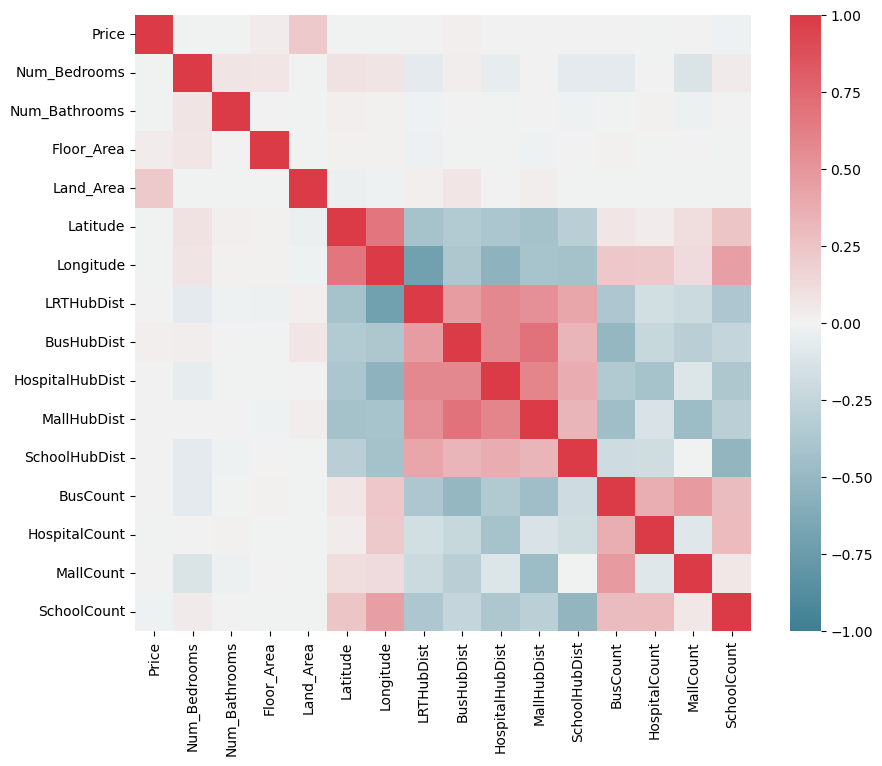

In [39]:
f, ax = plt.subplots(figsize=(10, 8))
corr = qgis_df.corr()
sns.heatmap(corr,
    cmap=sns.diverging_palette(220, 10, as_cmap=True),
    vmin=-1.0, vmax=1.0,
    square=True, ax=ax)

In [40]:
# Partial Match

In [41]:
# import pandas as pd
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.metrics.pairwise import cosine_similarity

# data = df['Description']
# vectorizer = TfidfVectorizer()
# X = vectorizer.fit_transform(data)

# similarity_matrix = cosine_similarity(X)

# similarity_df = pd.DataFrame(similarity_matrix, index=data, columns=data)

# threshold = 0.8
# similar_pairs = []
# for i in range(len(similarity_matrix)):
#     for j in range(i+1, len(similarity_matrix)):
#         if similarity_matrix[i][j] > threshold:
#             similar_pairs.append((data[i], data[j]))

# print(similar_pairs)

In [42]:
# qgis_df.to_csv("20241119 Properties Data.csv", encoding="utf-8-sig", index=False)